In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd /Users/armandoroqueestrada/Proyecto_Proca/stability

/Users/armandoroqueestrada/Proyecto_Proca/Stability


In [3]:
import Modules.Background as bg
import numpy as np

import matplotlib.pyplot as plt
import Modules.Plot as cplot

import matplotlib.patches as patches

In [4]:
cplot.general()

In [5]:
# Load the data

# n = 0
Real_Eingevalues_rad_polarization_Lsn0 = np.load("stability_lambda_s_case/Polarization_radial/Real_Eingevalues_rad_polarization_Lsn0.npy", allow_pickle=True)

# n = 1
Real_Eingevalues_rad_polarization_Lsn1 = np.load("stability_lambda_s_case/Polarization_radial/Real_Eingevalues_rad_polarization_Lsn1.npy", allow_pickle=True)


In [6]:
lambda_data_n0 = {'1': [], '-1': []}  # [[ls=1, [s0, ]], [ls=-1, [s0, ]]]
for dat_ in Real_Eingevalues_rad_polarization_Lsn0:
    temp = [[], []]
    s0, real_eigVal_list = dat_
    temp[0].append(s0); temp[1].append(s0)
    for i, dat2_ in enumerate(real_eigVal_list):
        lamV, real_eigVal = dat2_
        temp[i].append(real_eigVal)
    lambda_data_n0['1'].append(temp[0])
    lambda_data_n0['-1'].append(temp[1])

In [7]:
lambda_data_n1 = {'1': [], '-1': []}  # [[ls=1, [s0, ]], [ls=-1, [s0, ]]]
for dat_ in Real_Eingevalues_rad_polarization_Lsn1:
    temp = [[], []]
    s0, real_eigVal_list = dat_
    temp[0].append(s0); temp[1].append(s0)
    for i, dat2_ in enumerate(real_eigVal_list):
        lamV, real_eigVal = dat2_
        temp[i].append(real_eigVal)
    lambda_data_n1['1'].append(temp[0])
    lambda_data_n1['-1'].append(temp[1])

In [8]:
# Filtrando datos
from collections import defaultdict

def dividir_ramas(datos):
    ramas = defaultdict(list)

    # Agrupar por x
    grupos = defaultdict(list)
    for x, y in datos:
        grupos[x].append(y)

    # Ordenar y asignar a ramas
    for x in sorted(grupos.keys()):  # mantiene orden creciente en x
        # ys = sorted([y for y in grupos[x] if y is not None], reverse=True)
        ys = sorted(grupos[x], reverse=True)  # mayor a menor
        for idx, y in enumerate(ys):
            ramas[idx].append([x, y])

    # Convertir a lista de listas
    return [ramas[k] for k in sorted(ramas.keys())]

0.001 []
0.001 []
0.001 []
0.001 []
0.01 [-0.00024137+1.59407616e-14j  0.00024137+4.01172868e-15j]
0.01 []
0.01 []
0.01 []
0.05 [ 0.00068166+2.29830047e-13j -0.00068166-3.38341178e-14j
  0.00311852-8.00305692e-02j -0.00311852-8.00305692e-02j
  0.00311852-8.00305692e-02j -0.00311852-8.00305692e-02j
  0.00311852+8.00305692e-02j -0.00311852+8.00305692e-02j
  0.00311852+8.00305692e-02j -0.00311852+8.00305692e-02j]
0.05 []
0.05 []
0.05 []
0.1 [-0.0011581+4.50463039e-13j  0.0011581-1.68664561e-13j]
0.1 [ 0.00496522-0.13831188j -0.00496522-0.13831188j  0.00496522+0.13831188j
 -0.00496522+0.13831188j]
0.1 []
0.1 []
0.5 [ 0.0036023 +3.46017842e-12j -0.0036023 -3.05434921e-12j
  0.23010165+2.85826918e-13j -0.23010165+2.92377234e-13j
 -0.23010165+5.76760861e-14j  0.23010165+6.42224988e-14j]
0.5 [-0.04333293-0.34824056j  0.04333293-0.34824056j  0.04333293+0.34824056j
 -0.04333293+0.34824056j]
0.5 [-0.22512938+7.60218277e-13j  0.22512938+7.63333841e-13j]
0.5 []
0.8 [ 0.00483398+2.36307698e-12j -0.0

/Users/armandoroqueestrada/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/armandoroqueestrada/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


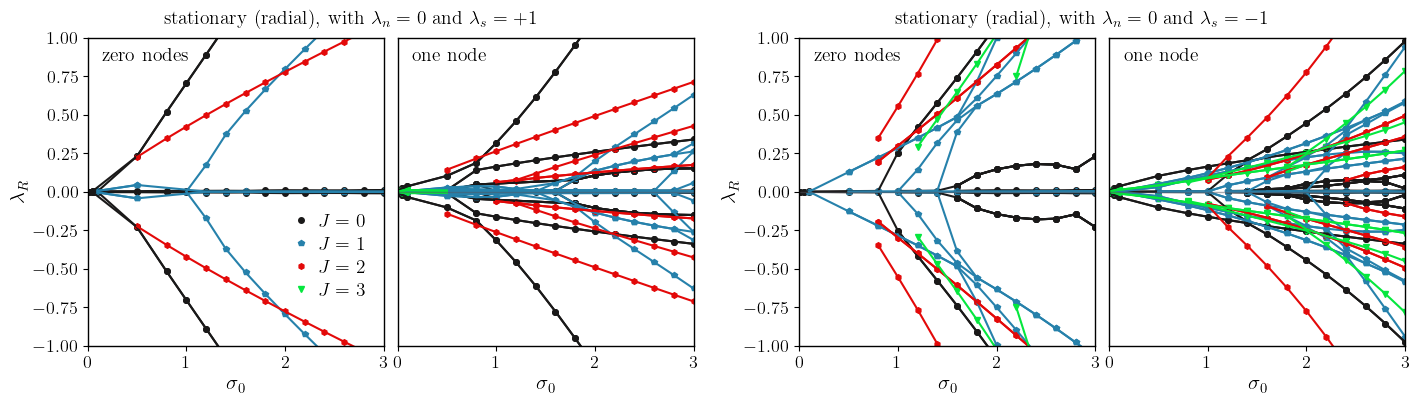

In [10]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e", "#e7ba05", "#a50979"]
mark = ['o', 'p', 'h', 'v', '*', 'x']

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(17, 4.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.5, wspace=.15) # espacio vertical y horizontal entre los subplots
                      )

# [Jval_temp, s0, r, eingVal, eigVect]
tempP, tempN = {'0': [], '1': [], '2': [], '3': [], '4': [], '5': []}, {'0': [], '1': [], '2': [], '3': [], '4': [], '5': []}
for dataExtra in [lambda_data_n0['1']]:
      for cont, [s0, dat_] in enumerate(dataExtra):
           for cond2, [Jval_temp, eingVal] in enumerate(dat_):
               #if Jval_temp in [1, 2, 3, 4, 5]:
               #     continue
               if Jval_temp == 2:
                    ind = np.abs(np.real(eingVal)) >= 6e-02
               else:
                    ind = np.abs(np.real(eingVal)) >= 1e-04 # filtrando los autovalores reales
               y = eingVal[ind]
               print(s0, y)
               x = [s0] * len(y)
               if cont == 0:
                    ax[0].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4, label=r'$J=%d$'%Jval_temp)
               else:
                    ax[0].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4)
               
               if len(y) == 0:
                    y = [None]

               for mod in np.real(y):
                   if mod is None or mod > 0:
                       tempP[str(Jval_temp)].append([s0, mod])
                   if mod is None or mod < 0:
                       tempN[str(Jval_temp)].append([s0, mod])


for cond2, key in enumerate(tempP.keys()):
    tempP[key] = np.array(tempP[key], dtype=object)
    # tempN[key] = np.array(tempN[key], dtype=object)
    plot_branch_P = dividir_ramas(tempP[key])
    # plot_branch_N = dividir_ramas(tempN[key])
    for i in range(len(plot_branch_P)):
        ax[0].plot(np.array(plot_branch_P[i])[:,0], np.array(plot_branch_P[i])[:, 1], color=col[cond2])
        arr_neg = np.array([x * -1 if x is not None else None for x in np.array(plot_branch_P[i])[:, 1]], dtype=object)
        ax[0].plot(np.array(plot_branch_P[i])[:, 0], arr_neg, color=col[cond2])
###################################
tempP, tempN = {'0': [], '1': [], '2': [], '3': [], '4': [], '5': []}, {'0': [], '1': [], '2': [], '3': [], '4': [], '5': []}
for dataExtra in [lambda_data_n1['1']]:
      for cont, [s0, dat_] in enumerate(dataExtra):
           #print(s0)
           for cond2, [Jval_temp, eingVal] in enumerate(dat_):
               #if Jval_temp in [1, 2, 3, 4, 5]:
               #     continue
               if Jval_temp == 2:
                    ind = np.abs(np.real(eingVal)) >= 6e-02
               else:
                    ind = np.abs(np.real(eingVal)) >= 1e-04 # filtrando los autovalores reales
               y = eingVal[ind]
               x = [s0] * len(y)
               if cont == 0:
                    ax[1].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4, label=r'$J=%d$'%Jval_temp)
               else:
                    ax[1].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4)
               
               if len(y) == 0:
                    y = [None]

               for mod in np.real(y):
                   if mod is None or mod > 0:
                       tempP[str(Jval_temp)].append([s0, mod])
                   if mod is None or mod < 0:
                       tempN[str(Jval_temp)].append([s0, mod])

for cond2, key in enumerate(tempP.keys()):
    tempP[key] = np.array(tempP[key], dtype=object)
    # tempN[key] = np.array(tempN[key], dtype=object)
    plot_branch_P = dividir_ramas(tempP[key])
    # plot_branch_N = dividir_ramas(tempN[key])
    for i in range(len(plot_branch_P)):
        ax[1].plot(np.array(plot_branch_P[i])[:,0], np.array(plot_branch_P[i])[:, 1], color=col[cond2])
        arr_neg = np.array([x * -1 if x is not None else None for x in np.array(plot_branch_P[i])[:, 1]], dtype=object)
        ax[1].plot(np.array(plot_branch_P[i])[:, 0], arr_neg, color=col[cond2])

###################################
tempP, tempN = {'0': [], '1': [], '2': [], '3': [], '4': [], '5': []}, {'0': [], '1': [], '2': [], '3': [], '4': [], '5': []}
for dataExtra in [lambda_data_n0['-1']]:
      for cont, [s0, dat_] in enumerate(dataExtra):
           for cond2, [Jval_temp, eingVal] in enumerate(dat_):
               #if Jval_temp in [1, 2, 3, 4, 5]:
               #     continue
               if Jval_temp == 2:
                    ind = np.abs(np.real(eingVal)) >= 1e-04
               else:
                    ind = np.abs(np.real(eingVal)) >= 1e-04 # filtrando los autovalores reales
               y = eingVal[ind]
               x = [s0] * len(y)
               print('->', s0, y)
               if cont == 0:
                    ax[2].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4, label=r'$J=%d$'%Jval_temp)
               else:
                    ax[2].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4)
               
               if len(y) == 0:
                    y = [None]

               for mod in np.real(y):
                   if mod is None or mod > 0:
                       tempP[str(Jval_temp)].append([s0, mod])
                   if mod is None or mod < 0:
                       tempN[str(Jval_temp)].append([s0, mod])

for cond2, key in enumerate(tempP.keys()):
    tempP[key] = np.array(tempP[key], dtype=object)
    # tempN[key] = np.array(tempN[key], dtype=object)
    plot_branch_P = dividir_ramas(tempP[key])
    # plot_branch_N = dividir_ramas(tempN[key])
    for i in range(len(plot_branch_P)):
        ax[2].plot(np.array(plot_branch_P[i])[:,0], np.array(plot_branch_P[i])[:, 1], color=col[cond2])
        arr_neg = np.array([x * -1 if x is not None else None for x in np.array(plot_branch_P[i])[:, 1]], dtype=object)
        ax[2].plot(np.array(plot_branch_P[i])[:, 0], arr_neg, color=col[cond2])

###################################
tempP, tempN = {'0': [], '1': [], '2': [], '3': [], '4': [], '5': []}, {'0': [], '1': [], '2': [], '3': [], '4': [], '5': []}
for dataExtra in [lambda_data_n1['-1']]:
      for cont, [s0, dat_] in enumerate(dataExtra):
           for cond2, [Jval_temp, eingVal] in enumerate(dat_):
               #if Jval_temp in [1, 2, 3, 4, 5]:
               #     continue
               if Jval_temp == 2:
                    ind = np.abs(np.real(eingVal)) >= 6e-02
               else:
                    ind = np.abs(np.real(eingVal)) >= 1e-04 # filtrando los autovalores reales
               y = eingVal[ind]
               x = [s0] * len(y)
               if cont == 0:
                    ax[3].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4, label=r'$J=%d$'%Jval_temp)
               else:
                    ax[3].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4)
               
               if len(y) == 0:
                    y = [None]

               for mod in np.real(y):
                   if mod is None or mod > 0:
                       tempP[str(Jval_temp)].append([s0, mod])
                   if mod is None or mod < 0:
                       tempN[str(Jval_temp)].append([s0, mod])

for cond2, key in enumerate(tempP.keys()):
    tempP[key] = np.array(tempP[key], dtype=object)
    # tempN[key] = np.array(tempN[key], dtype=object)
    plot_branch_P = dividir_ramas(tempP[key])
    # plot_branch_N = dividir_ramas(tempN[key])
    for i in range(len(plot_branch_P)):
        ax[3].plot(np.array(plot_branch_P[i])[:,0], np.array(plot_branch_P[i])[:, 1], color=col[cond2])
        arr_neg = np.array([x * -1 if x is not None else None for x in np.array(plot_branch_P[i])[:, 1]], dtype=object)
        ax[3].plot(np.array(plot_branch_P[i])[:, 0], arr_neg, color=col[cond2])

#############


ax[1].set_yticks([])
ax[3].set_yticks([])
ax[0].set_ylabel(r'$\lambda_{R}$')
ax[2].set_ylabel(r'$\lambda_{R}$')


# Añadir una etiqueta para el marco exterior
fig.text(
    x=0.28, y=0.95,                    # posición (x, y) relativa a la figura
    s=r'stationary (radial), with $\lambda_n= 0$ and $\lambda_s=+1$',          # texto
    ha='center', va='top',        # alineación horizontal y vertical
    fontsize=14, color='k',
    weight='bold'
)


fig.text(
    x=0.71, y=0.95,                    # posición (x, y) relativa a la figura
    s=r'stationary (radial), with $\lambda_n= 0$ and $\lambda_s=-1$',          # texto
    ha='center', va='top',        # alineación horizontal y vertical
    fontsize=14, color='k',
    weight='bold'
)

# Obtener posiciones originales
pos2 = ax[1].get_position()
pos3 = ax[2].get_position()

# Acercar la segunda y tercera columna
ax[1].set_position([pos2.x0 - 0.018, pos2.y0, pos2.width, pos2.height])
ax[2].set_position([pos3.x0 + 0.018, pos3.y0, pos3.width, pos3.height])

for axes in ax:
    axes.set_xlim(0, 3)
    axes.set_ylim(-1., 1.)
    axes.set_xlabel(r'$\sigma_0$')


#ax[0].hlines(y=0, xmin=0, xmax=3.3, ls='-', lw=1, color='#55555e', alpha=0.5)
#ax[0].hlines(y=0, xmin=7.4, xmax=11.5, ls='-', lw=1, color='#55555e', alpha=0.5)

ax[1].hlines(y=0, xmin=0, xmax=11.5, ls='-', lw=1, color='#55555e', alpha=0.5)
ax[2].hlines(y=0, xmin=0, xmax=11.5, ls='-', lw=1, color='#55555e', alpha=0.5)
ax[3].hlines(y=0, xmin=0, xmax=50, ls='-', lw=1, color='#55555e', alpha=0.5)

#ax[0].text(3.5, -0.03, s=r'stable band', rotation='horizontal')#, fontsize='small'

ax[0].axvspan(0, 0.01, facecolor='#656473', alpha=0.5)
ax[2].axvspan(0, 0.01, facecolor='#656473', alpha=0.5)
#ax[2].axvspan(0, 1.046, facecolor='#656473', alpha=0.5)
#ax[2].text(0.25, .25, s=r'stable band', rotation='vertical')#, fontsize='small'

ax[0].text(x=0.15, y=0.85, s=r'zero nodes', fontsize=14)
ax[2].text(x=0.15, y=0.85, s=r'zero nodes', fontsize=14)
ax[1].text(x=0.15, y=0.85, s=r'one node', fontsize=14)
ax[3].text(x=0.15, y=0.85, s=r'one node', fontsize=14)

ax[0].legend(loc=(0.65, 0.13),frameon=False, fontsize=14, ncols=1, columnspacing=1.5, handletextpad=0.2, handlelength=1.5, labelspacing=0.3, borderpad=0.3)
#ax[1].axvline(0.5, -1, 1)

In [50]:
fig.savefig('stationary_radial_lambda_s.pdf', format='pdf', metadata=None, # dpi='figure',
        pad_inches=0.1,
        facecolor='auto', edgecolor='auto',
        backend=None, dpi=1000, 
        bbox_inches='tight'# Plot will be occupy a maximum of available space # bbox_inches=None,
       )